<a href="https://colab.research.google.com/github/fynoeb/ImageProcessing/blob/main/Image_Processing_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

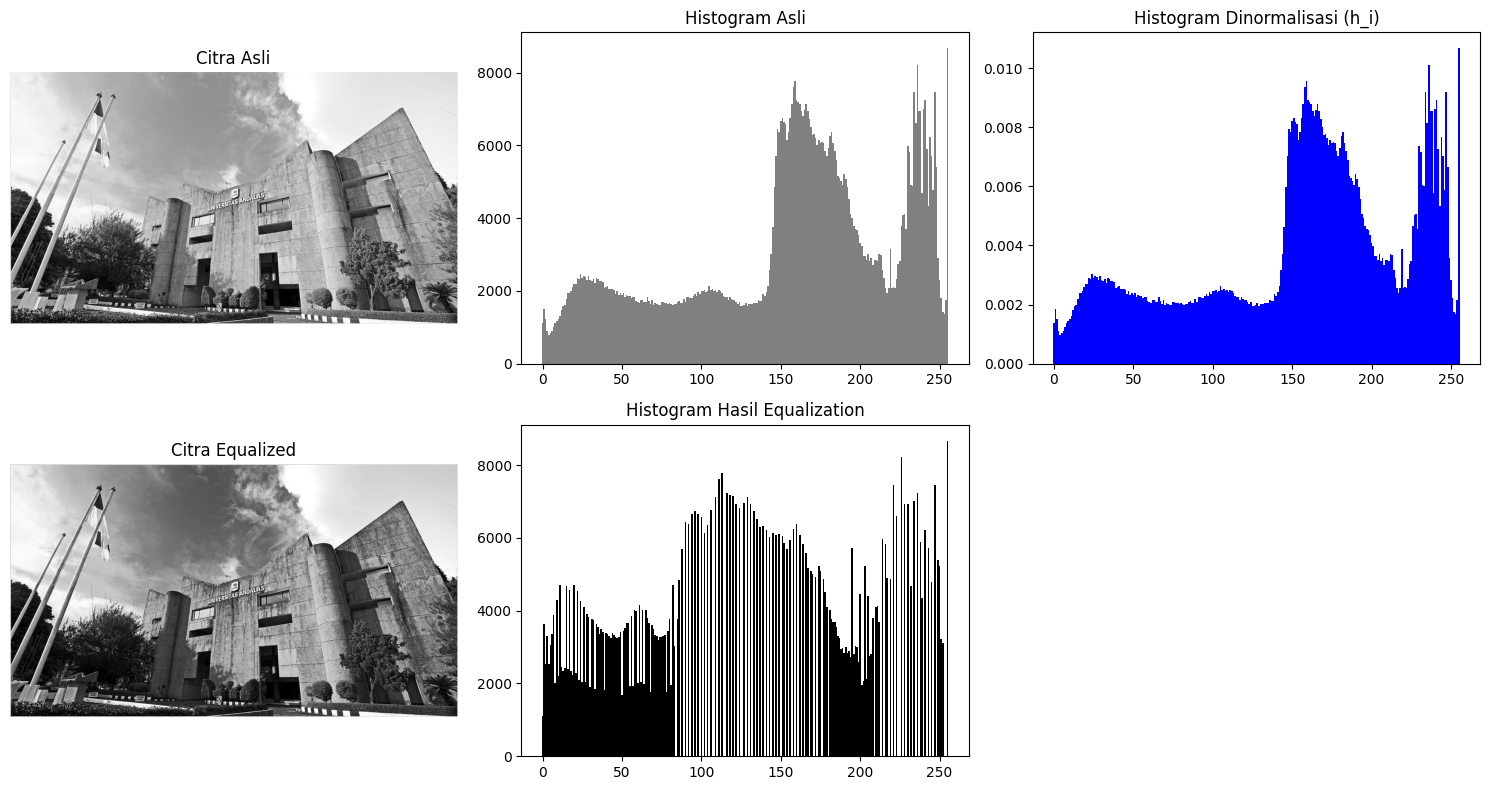

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def compute_histogram(image):
    """Menghitung histogram citra secara manual."""
    hist = np.zeros(256, dtype=int)
    for row in image:
        for pixel in row:
            hist[pixel] += 1
    return hist

def normalize_histogram(hist, total_pixels):
    """Normalisasi histogram membagi frekuensi dengan total pixel (hi = ni / n)."""
    return hist / total_pixels

def equalize_histogram(image, normalized_hist):
    """Melakukan histogram equalization menggunakan distribusi kumulatif."""
    # 1. Menghitung probabilitas kumulatif (CDF - Cumulative Distribution Function)
    cdf = np.zeros(256, dtype=float)
    cdf[0] = normalized_hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + normalized_hist[i]

    # 2. Mengalikan CDF dengan nilai maksimum derajat keabuan (255) dan membulatkan
    equalized_mapping = np.round(cdf * 255).astype(np.uint8)

    # 3. Menerapkan pemetaan nilai pixel baru ke citra asli
    equalized_image = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            equalized_image[i, j] = equalized_mapping[image[i, j]]

    return equalized_image

image = cv2.imread('gambar_input.jpg', cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Error: Citra tidak ditemukan!")
else:
    # Menghitung total piksel (M * N)
    total_pixels = image.shape[0] * image.shape[1]

    # 2. Menghitung histogram asli
    hist_original = compute_histogram(image)

    # 3. Normalisasi histogram
    hist_normalized = normalize_histogram(hist_original, total_pixels)

    # 4. Melakukan Histogram Equalization
    equalized_img = equalize_histogram(image, hist_normalized)

    # Menghitung histogram dari citra hasil equalization untuk ditampilkan
    hist_equalized = compute_histogram(equalized_img)

    # --- VISUALISASI HASIL ---
    plt.figure(figsize=(15, 8))

    # Citra Asli
    plt.subplot(2, 3, 1)
    plt.title("Citra Asli")
    plt.imshow(image, cmap='gray')
    plt.axis('off')

    # Histogram Asli (Frekuensi)
    plt.subplot(2, 3, 2)
    plt.title("Histogram Asli")
    plt.bar(range(256), hist_original, width=1, color='gray')

    # Histogram Normalisasi (Probabilitas)
    plt.subplot(2, 3, 3)
    plt.title("Histogram Dinormalisasi (h_i)")
    plt.bar(range(256), hist_normalized, width=1, color='blue')

    # Citra Hasil Equalization
    plt.subplot(2, 3, 4)
    plt.title("Citra Equalized")
    plt.imshow(equalized_img, cmap='gray')
    plt.axis('off')

    # Histogram Hasil Equalization
    plt.subplot(2, 3, 5)
    plt.title("Histogram Hasil Equalization")
    plt.bar(range(256), hist_equalized, width=1, color='black')

    plt.tight_layout()
    plt.show()